In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.riemannian_autoencoder.vector.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.pullback.standard import StandardPullbackVectorRiemannianAutoencoder
from src.transforms.lower_triangular_linear import LowerTriangularLinearTransform
from src.transforms.upper_triangular_linear import UpperTriangularLinearTransform
from src.transforms.parity.polynomial import PolynomialParityTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

### Learning Geometry ###

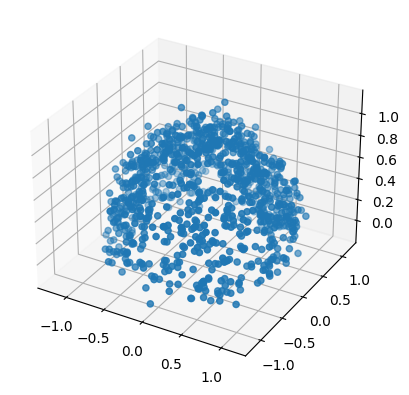

In [2]:
# Construct dataset
def uniform_sphere_sampling(dim, num_samples):
    """
    Generate uniform samples on a unit sphere in dim dimensions using PyTorch.
    """
    samples = torch.randn(num_samples, dim)
    samples /= torch.norm(samples, dim=1, keepdim=True)
    samples[:,2] *= torch.sign(samples[:,2])
    return samples

num_samples = 1000
noise_level = 0.1

data_train_clean = uniform_sphere_sampling(3, num_samples)
data_train = data_train_clean + noise_level * torch.randn_like(data_train_clean)

train_loader = DataLoader(data_train, batch_size=128, shuffle=False)

# plot data
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
plt.show()

In [3]:
class IdentityForward(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return x

In [4]:
# Define the normalizing flow model
def create_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.StandardNormal(shape=[dim])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [5]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(dim, n_flows, order, unit_det=False):
    base_dist = distributions.ConditionalDiagonalNormal(shape=[dim], context_encoder=nn.Linear(dim, 2 * dim))
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
        transforms_list.append(PolynomialParityTransform(dim, order=order, parity=i))
    transforms_list.append(UpperTriangularLinearTransform(dim, unit_det=unit_det))
    transforms_list.append(LowerTriangularLinearTransform(dim, unit_det=unit_det))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [6]:
# Initialize the model
forward = IdentityForward()

dim = 3
n_flows = 2
flow = create_flow_model(dim, n_flows, 2)
prior_diffeo = NFlowVectorDiffeomorphism(dim, flow)

n_layers = 2
c_flow = create_conditional_flow_model(dim, n_flows, 2)
posterior_diffeo = NFlowVectorDiffeomorphism(dim, c_flow)

model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=0.1).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# Training loop
def train(model, train_loader, optimizer, n_epochs):
    for epoch in range(n_epochs):
        for _, y in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()
            
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss.item():.4f}")

In [8]:
# Train the model
n_epochs = 500
train(model, train_loader, optimizer, n_epochs)

Epoch 1/500, Loss: 66.2358
Epoch 2/500, Loss: 48.9310
Epoch 3/500, Loss: 60.7272
Epoch 4/500, Loss: 40.2144
Epoch 5/500, Loss: 39.1840
Epoch 6/500, Loss: 36.4214
Epoch 7/500, Loss: 31.1089
Epoch 8/500, Loss: 34.5251
Epoch 9/500, Loss: 24.6959
Epoch 10/500, Loss: 27.8309
Epoch 11/500, Loss: 27.6342
Epoch 12/500, Loss: 25.5822
Epoch 13/500, Loss: 28.1251
Epoch 14/500, Loss: 23.1195
Epoch 15/500, Loss: 23.0573
Epoch 16/500, Loss: 23.3967
Epoch 17/500, Loss: 23.3850
Epoch 18/500, Loss: 21.3234
Epoch 19/500, Loss: 20.2576
Epoch 20/500, Loss: 20.5344
Epoch 21/500, Loss: 19.8812
Epoch 22/500, Loss: 17.8734
Epoch 23/500, Loss: 19.5215
Epoch 24/500, Loss: 20.4259
Epoch 25/500, Loss: 18.2129
Epoch 26/500, Loss: 16.9170
Epoch 27/500, Loss: 17.1974
Epoch 28/500, Loss: 18.5413
Epoch 29/500, Loss: 16.4155
Epoch 30/500, Loss: 16.2697
Epoch 31/500, Loss: 16.2829
Epoch 32/500, Loss: 16.6062
Epoch 33/500, Loss: 14.9719
Epoch 34/500, Loss: 15.9429
Epoch 35/500, Loss: 14.3985
Epoch 36/500, Loss: 16.2955
E

In [9]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [10]:
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

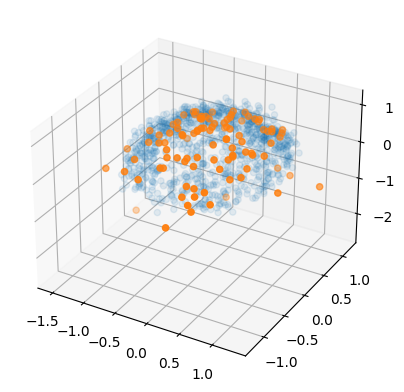

In [11]:
# Visualize generated samples
samples = generate_samples(model.phi.nflow, 100)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
plt.show()

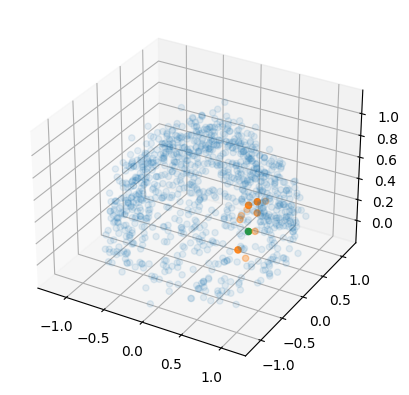

In [12]:
# Visualize generated samples
context = data_train[8]
samples = generate_samples_with_context(model.phy.nflow, 10, context)

ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2],alpha=0.1)
ax.scatter(samples[:,0], samples[:,1], samples[:,2])
ax.scatter(context[0], context[1], context[2])
plt.show()

### Evaluating Geometry ###

In [13]:
# Construct pullback manifold
manifold = StandardPullbackVectorEuclidean(model.phi)

In [14]:
# special points
x0 = torch.tensor([0.,0.,1.]).to(device)
x1 = torch.tensor([1.,0.,0.]).to(device)

In [15]:
# test interpolation
t = torch.linspace(0.,1.,20).to(device)

geodesic_x0_x1 = manifold.geodesic(x0,x1,t).detach().cpu().numpy()

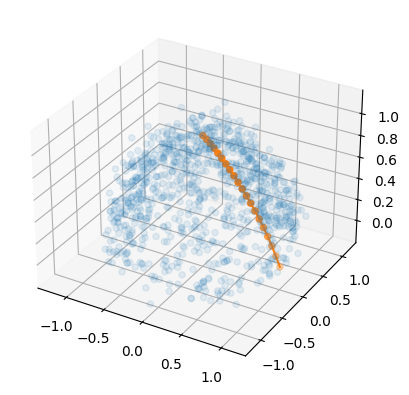

In [16]:
# plot geodesics
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
ax.scatter(geodesic_x0_x1[:,0], geodesic_x0_x1[:,1], geodesic_x0_x1[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

#### RAE construction ####

##### Tangent space PCA #####

In [17]:
# compute barycentre
bary = manifold.barycentre(data_train.to(device))
print(bary)

tensor([ 0.1122, -0.1265,  0.9206], grad_fn=<SelectBackward0>)


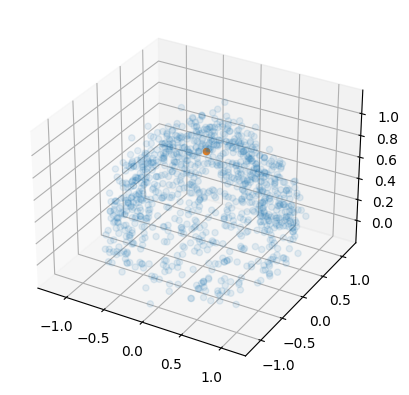

In [18]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [19]:
# construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCAVectorSolver(data_train.to(device), manifold, bary)

In [20]:
# compute low rank approximations
Xi, approximations, _ = l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


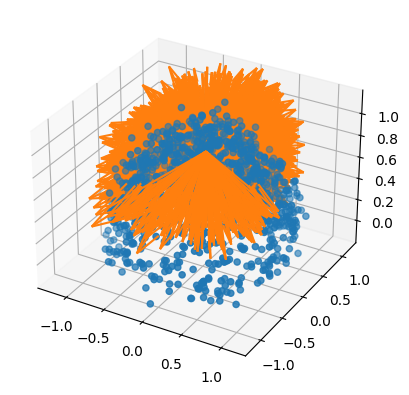

In [21]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(bary.detach().cpu().numpy()[0], bary.detach().cpu().numpy()[1], bary.detach().cpu().numpy()[2], 
             Xi.detach().cpu().numpy()[i, 0], Xi.detach().cpu().numpy()[i, 1], Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


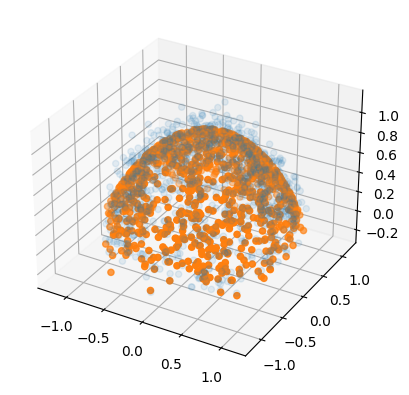

In [22]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(approximations.detach().cpu().numpy()[:,0], approximations.detach().cpu().numpy()[:,1], approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [23]:
# compute approximation errors
print(torch.mean((data_train.to(device) - approximations)**2,0).sum())

tensor(0.0282)


##### Standard Normalizing Flow RAE #####

In [24]:
# Construct RAE
epsilon = 0.1
d_epsilon = 2
rae_ = StandardPullbackVectorRiemannianAutoencoder(manifold, epsilon=epsilon)
rae = StandardPullbackVectorRiemannianAutoencoder(manifold, d_epsilon=d_epsilon)

0 | sigma = 0.5124788880348206 with u = tensor([-0.4078, -0.6343, -0.6568])
1 | sigma = 0.33247989416122437 with u = tensor([-0.8985,  0.1507,  0.4123])
2 | sigma = 0.012636587023735046 with u = tensor([ 0.1625, -0.7583,  0.6313])
constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.0147349052131176
0 | sigma = 0.5124788880348206 with u = tensor([-0.4078, -0.6343, -0.6568])
1 | sigma = 0.33247989416122437 with u = tensor([-0.8985,  0.1507,  0.4123])
2 | sigma = 0.012636587023735046 with u = tensor([ 0.1625, -0.7583,  0.6313])
constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.0147349052131176


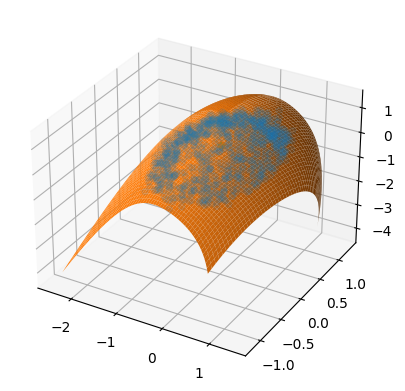

In [25]:
L = 50
x = torch.linspace(-1.5, 1.5, steps=L, device=device)
y = torch.linspace(-1.5, 1.5, steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = rae.decode(coordinates)  
    x_bar = manifold.phi.inverse(torch.zeros(1,3,device=x.device))[0].cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [26]:
rae_approximations = rae.project_on_manifold(data_train.to(device)).detach().cpu().numpy()

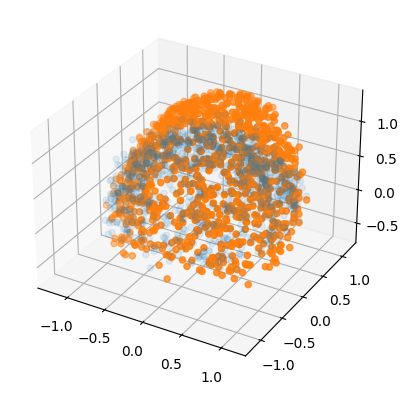

In [27]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rae_approximations[:,0], rae_approximations[:,1], rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [28]:
# compute approximation errors
print(torch.mean((data_train.to(device) - rae_approximations)**2,0).sum())

tensor(0.2844)


##### Posterior Tangent Space PCA #####

In [29]:
# use all data to sample from the learned conditional (and take the mean per conditioning data point)
# do tangent space pca wrt to the prior diffeomorphism to get the subspace
rec_data_train = torch.zeros(data_train.shape[0], 3)
for i, context in enumerate(data_train):
    samples = generate_samples_with_context(model.phy.nflow, 10, context)
    rec_data_train[i] = samples.mean(0)

In [30]:
# compute barycentre
rec_bary = manifold.barycentre(rec_data_train.to(device))
print(rec_bary)

tensor([ 0.1022, -0.0924,  0.8958], grad_fn=<SelectBackward0>)


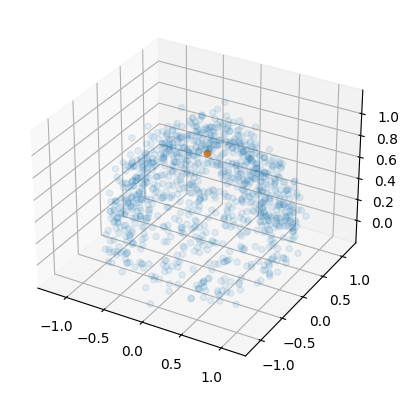

In [31]:
# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [ ]:
# construct l2-pga solver
rec_l2_pga_solver = l2TangentSpacePCAVectorSolver(rec_data_train.to(device), manifold, rec_bary)

In [33]:
# compute low rank approximations
rec_Xi, rec_approximations, _ = rec_l2_pga_solver.solve(2)

Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


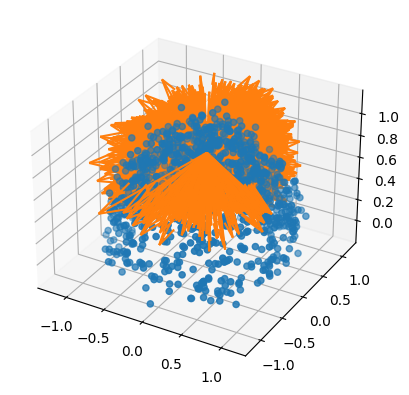

In [34]:
# plot tangent space approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2])
ax.scatter(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
for i in range(rec_l2_pga_solver.log_x_data.shape[0]):
    ax.quiver(rec_bary.detach().cpu().numpy()[0], rec_bary.detach().cpu().numpy()[1], rec_bary.detach().cpu().numpy()[2], 
             rec_Xi.detach().cpu().numpy()[i, 0], rec_Xi.detach().cpu().numpy()[i, 1], rec_Xi.detach().cpu().numpy()[i, 2], 
             color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()


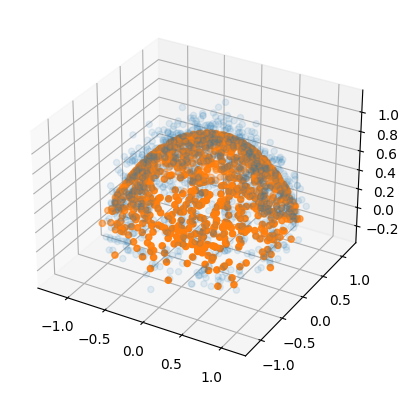

In [35]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_approximations.detach().cpu().numpy()[:,0], rec_approximations.detach().cpu().numpy()[:,1], rec_approximations.detach().cpu().numpy()[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [36]:
print(torch.mean((data_train.to(device) - rec_approximations)**2,0).sum())
print(torch.mean((rec_data_train.to(device) - rec_approximations)**2,0).sum())

tensor(0.0398)
tensor(0.0182)


##### Posterior RAE #####

In [37]:
l2_tpca_rae = l2TangentSpacePCAPullbackVectorRiemannianAutoencoder(manifold, rec_data_train, 2)

In [38]:
print(l2_pga_solver.base_point.shape)

torch.Size([3])


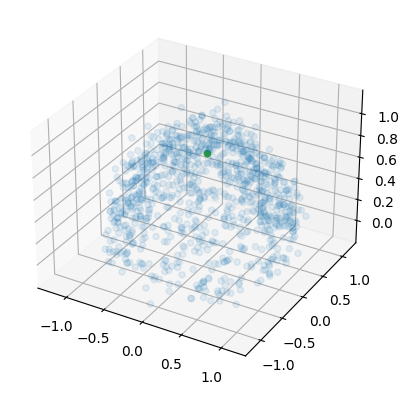

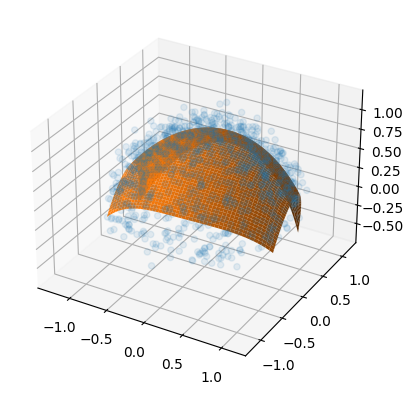

In [ ]:
L = 50
x = torch.linspace(-1., 1., steps=L, device=device)
y = torch.linspace(-1., 1., steps=L, device=device)
grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

coordinates = torch.stack([grid_x.flatten(), grid_y.flatten()], dim=1)
with torch.no_grad():
    decoded = l2_tpca_rae.decode(coordinates)  
    x_bar = l2_tpca_rae.base_point.detach().cpu()
X = decoded[:, 0].reshape(L, L).cpu()
Y = decoded[:, 1].reshape(L, L).cpu()
Z = decoded[:, 2].reshape(L, L).cpu()

# plot barycentres
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(x_bar[0], x_bar[1], x_bar[2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2])
plt.show()

# Create 3D plot
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.plot_surface(X, Y, Z, color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [44]:
rec_l2_tpca_rae_approximations = l2_tpca_rae.project_on_manifold(rec_data_train.to(device)).detach().cpu().numpy()

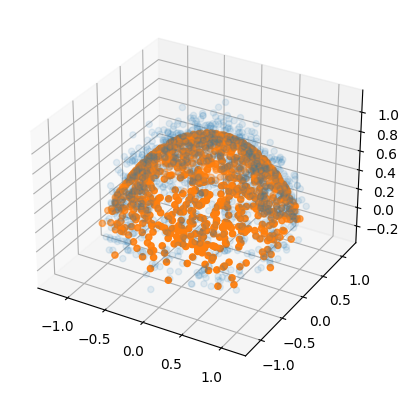

In [46]:
# plot data approximations
ax = plt.axes(projection='3d')
ax.scatter(data_train[:,0], data_train[:,1], data_train[:,2], alpha=0.1)
ax.scatter(rec_l2_tpca_rae_approximations[:,0], rec_l2_tpca_rae_approximations[:,1], rec_l2_tpca_rae_approximations[:,2], color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1])
plt.show()

In [47]:
# compute approximation errors
print(torch.mean((rec_data_train.to(device) - rec_l2_tpca_rae_approximations)**2,0).sum())

tensor(0.0182)
